<h1>
  <b>&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp Time series forecasting</b>
</h1>

## Project summary <br>
#### Dataset:  Walmart weekly sales data, 45 stores, Feb 2010 – Oct 2012. <br>
#### Scope:    Store 1 — 143 weekly observations. <br>
#### Goal:     Build a SARIMAX model to forecast future weekly sales. <br>
#### Model:    SARIMAX(1,0,1)(0,1,0)[52] with CPI as exogenous variable. <br>
#### Result:   MAPE 2.50%, RMSE $53,736 on held-out test set (18% of data). <br>
#### Forecast: 20-week forward forecast with 95% confidence intervals.

In [14]:
!pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.3 MB/s eta 0:00:00


#### installing pmdarima for using auto arima

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima.arima.utils import nsdiffs
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

## <b> Adding dataset

In [16]:
df = pd.read_csv('Walmart Data Analysis and Forcasting.csv')

## <b> Doing basic EDA

In [ ]:
df.shape

(6435, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


#### Looking at the store columns we can say the the data used here are store no. from 1 to 45

In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [ ]:
columns = df.select_dtypes(include='number').columns

#### Checking for outliers

/tmp/ipykernel_1685/3864601094.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[col].dropna(), labels=[col], showfliers=True)
/tmp/ipykernel_1685/3864601094.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[col].dropna(), labels=[col], showfliers=True)
/tmp/ipykernel_1685/3864601094.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[col].dropna(), labels=[col], showfliers=True)
/tmp/ipykernel_1685/3864601094.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

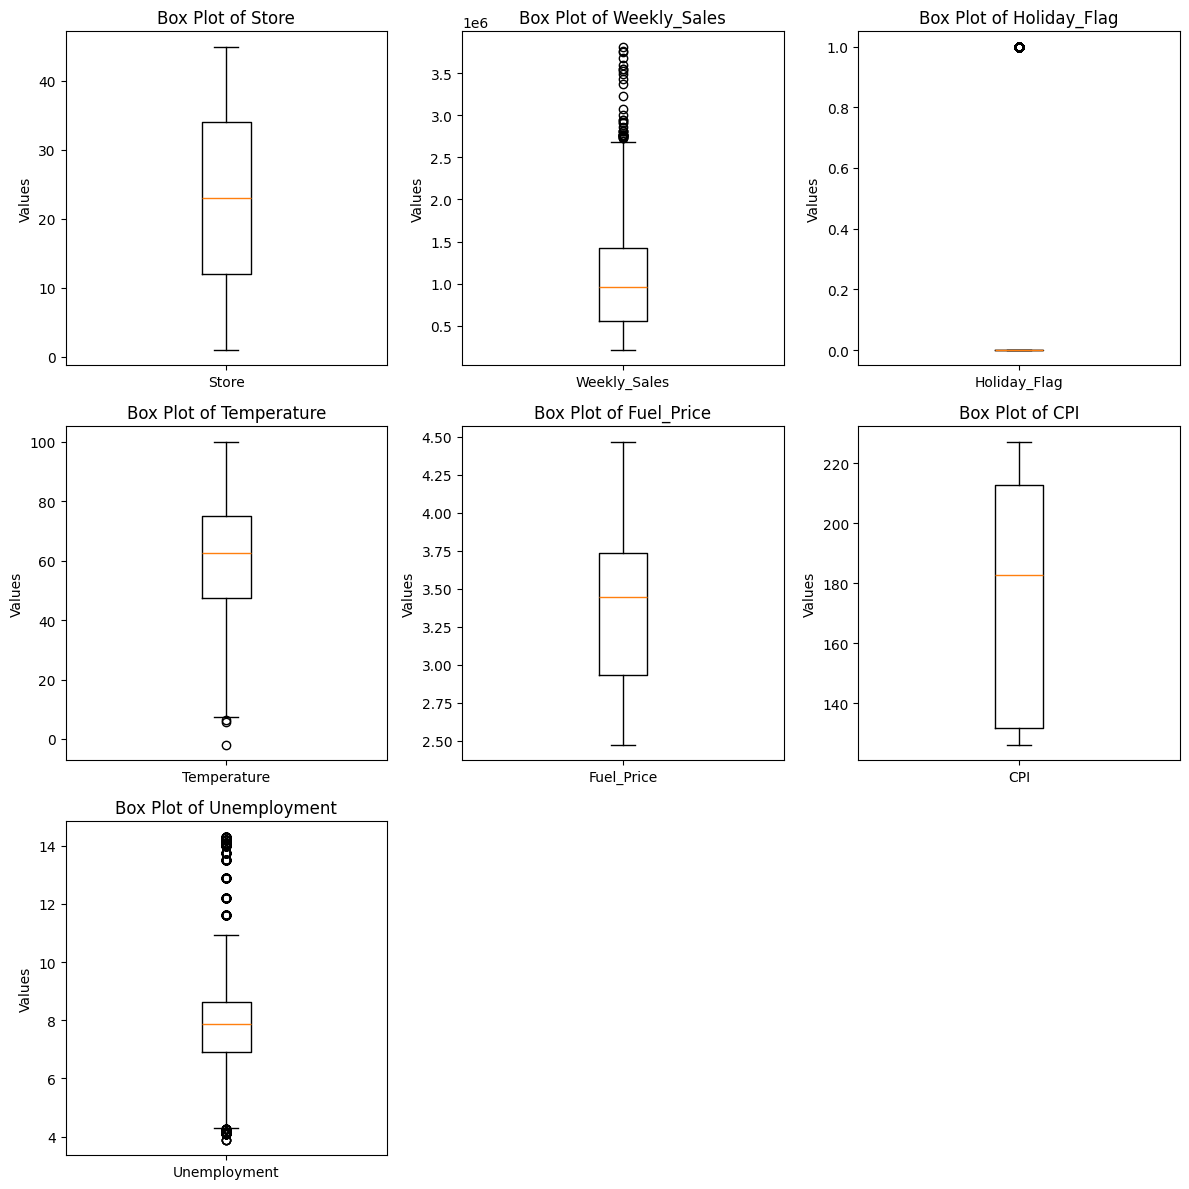

In [ ]:
cols = 3
num_rows = math.ceil(len(columns)/ cols)

plt.figure(figsize=(12, 4 * num_rows))

for i, col in enumerate(columns):
    plt.subplot(num_rows, cols, i + 1)

    plt.boxplot(df[col].dropna(), labels=[col], showfliers=True)
    plt.title(f"Box Plot of {col}")
    plt.ylabel("Values")

plt.tight_layout()
plt.show()

#### Converting Date column to datatime datatype and then using this as indexing

In [17]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.set_index('Date')

#### As discused earlier that there are 1 - 45 no. of stores for Walmart. To make the analysis easier I will only do forecasting for the store no. 1.

In [18]:
store_df = df[df['Store'] == 1]

#### Using asfreq('W_FRI') to fill missing values as nan value and to convert time series to weekly.

In [19]:
store_df = store_df.asfreq('W-FRI')

#### Plotting the sales data into a graph

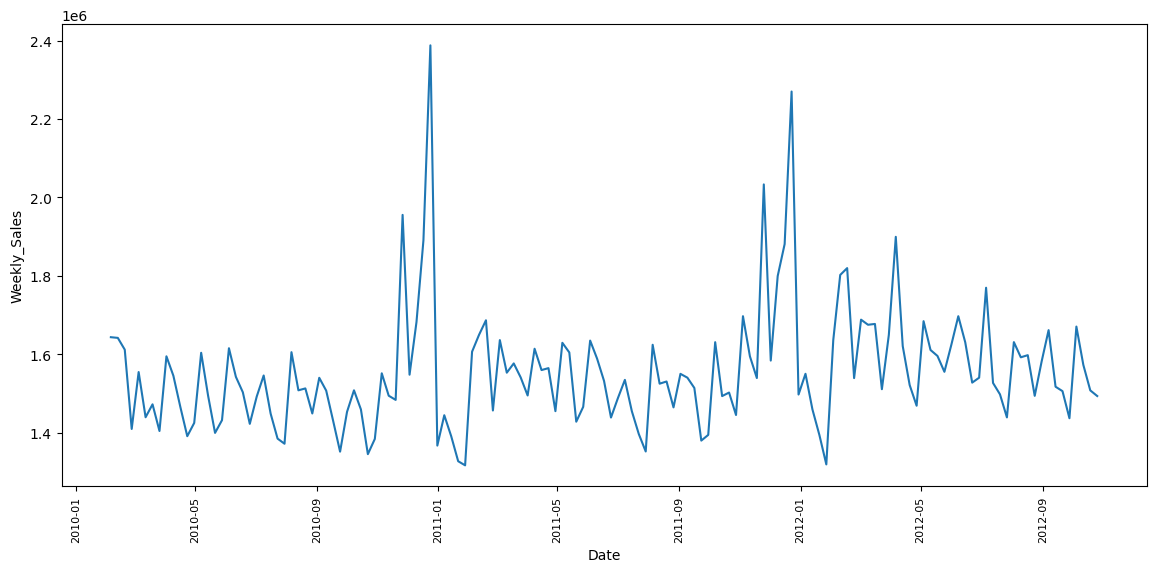

In [7]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=store_df)
plt.xticks(rotation=90, fontsize = 8)
plt.show()

#### Zooming into the dataset

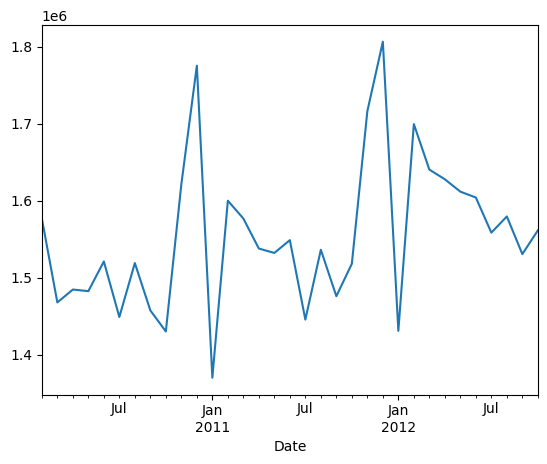

In [ ]:
store_df.resample('ME').mean()['Weekly_Sales'].plot()
plt.show()

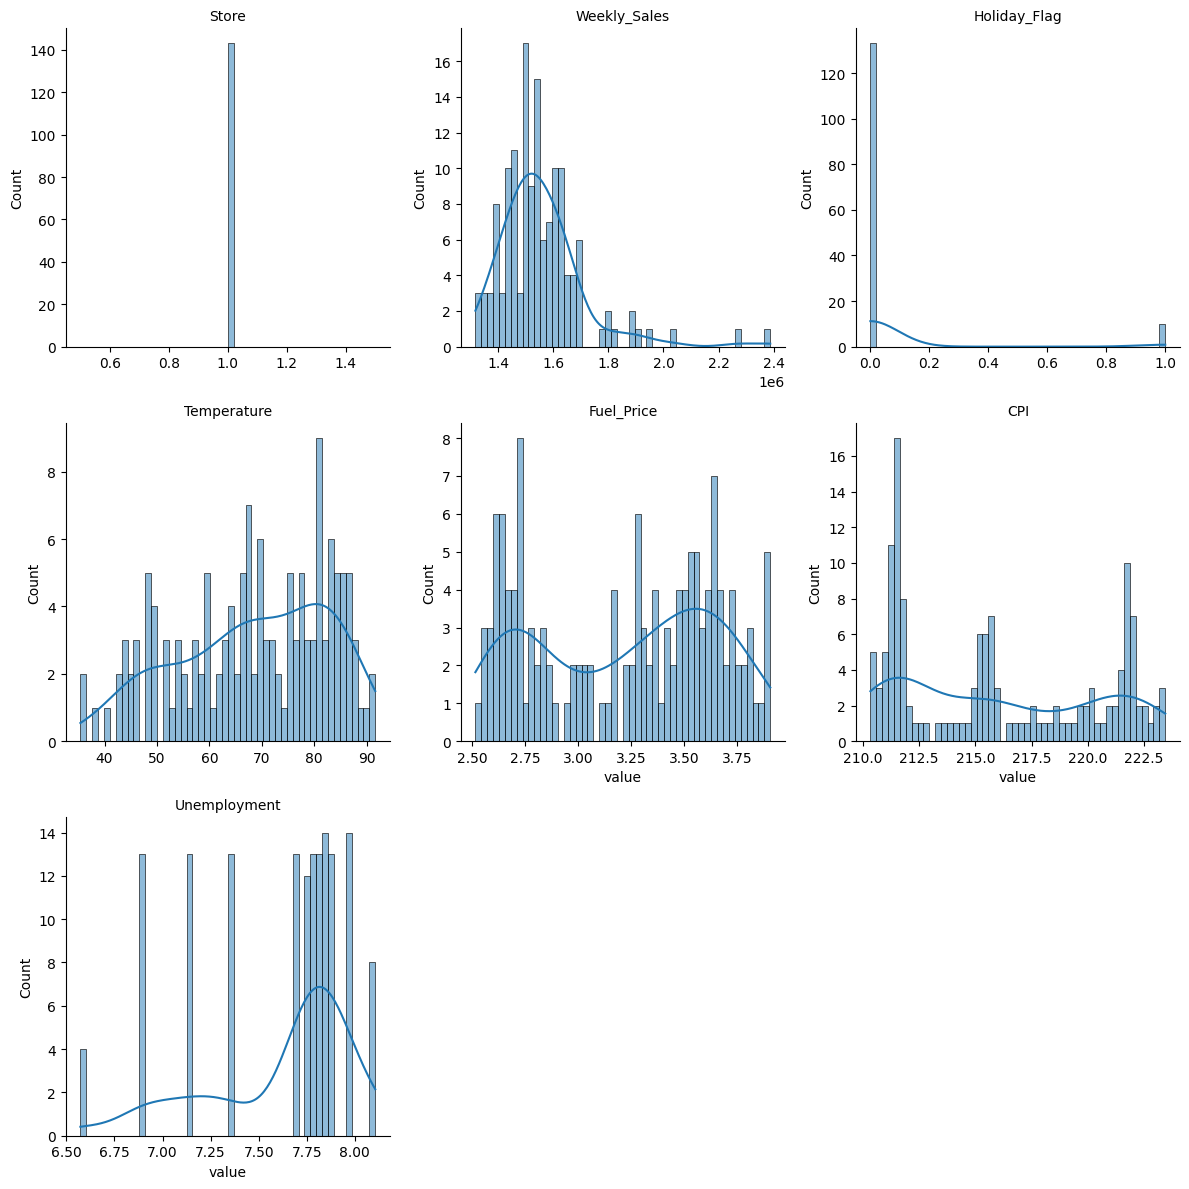

In [ ]:
df_melted = store_df.melt()
g = sns.FacetGrid(df_melted, col="variable", col_wrap=3, sharex=False, sharey=False, height=4)
g.map(sns.histplot, "value", bins=50, kde=True)

g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

#### Checking the correlation heatmap with sales data

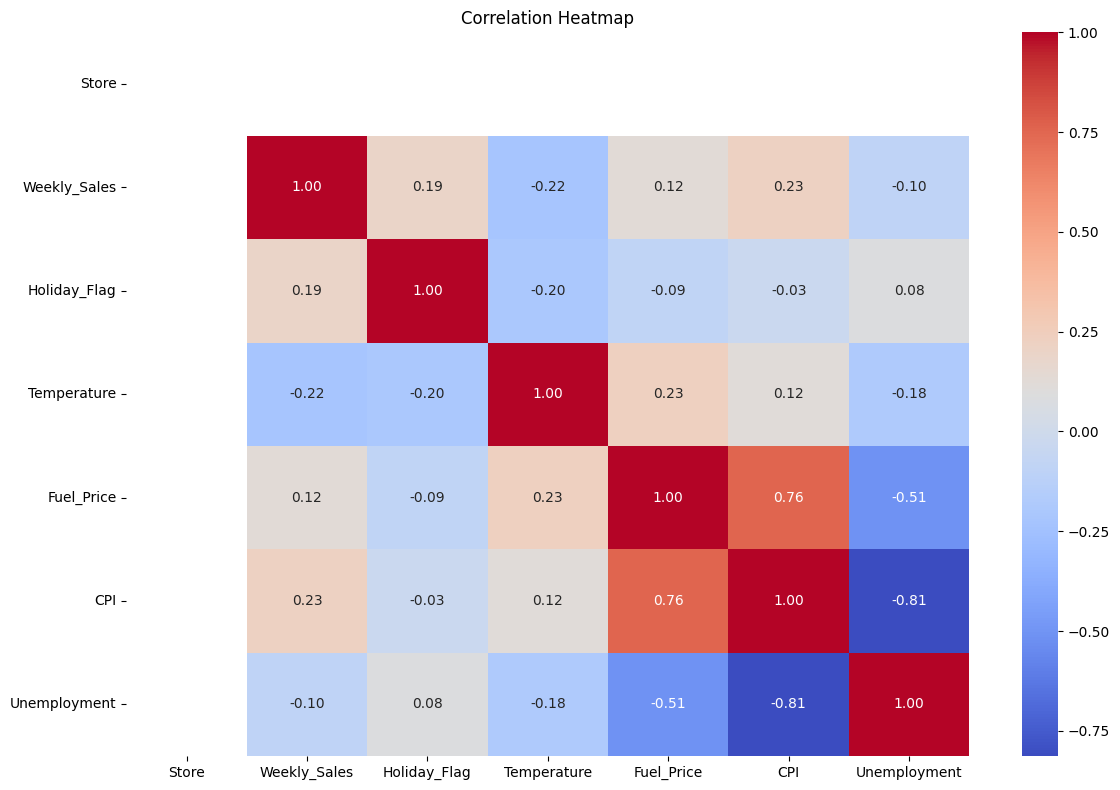

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    store_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### The two highest positively corelated with Weekly_Sales column is Holiday_Flags and CPI

## <b> Data decomposition

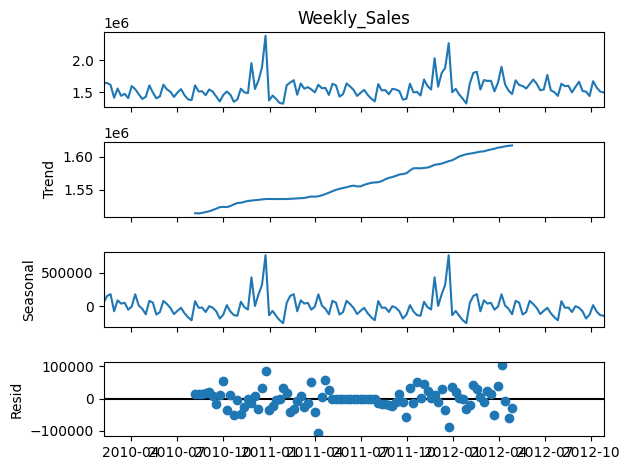

In [ ]:
decomp = seasonal_decompose(store_df['Weekly_Sales'], model='additive', period=52)
decomp.plot(); # doesn't show the return object

#### With the data decomposition I can say that this is a seasonal data with trends.

## <b> Finding best model and model parameters (p,d,q) for this project

#### Usually its right practice to first look for the differencing value or checking the data stationality but here I will first perform ACF and PACF to check for seasonality.

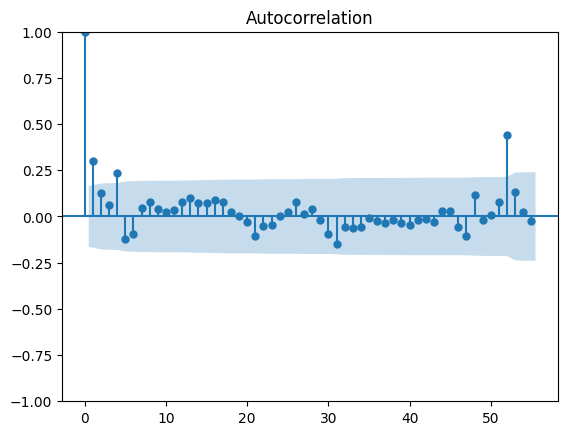

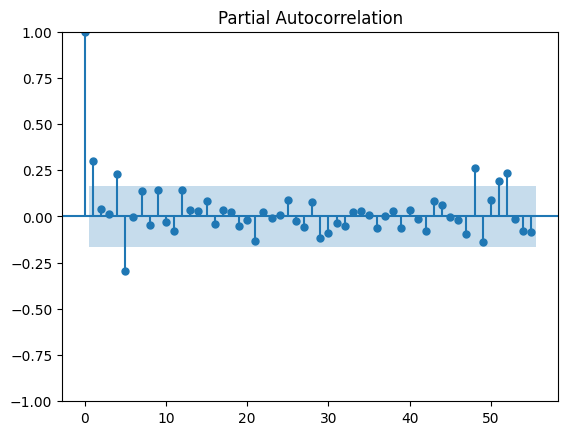

In [ ]:
plot_acf(store_df['Weekly_Sales'].dropna(), lags=55);
plot_pacf(store_df['Weekly_Sales'].dropna(), lags=55);

#### There is a spike at lag 52. This could mean one thing, that todays data is corelated with last years data (we have weekly data). So this data is seasonal hand the seasonal period is 52 weeks.

## <b> Cheking whether the data is stationary or not

#### For this I will perform Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test

In [ ]:
# Applying ADF test
result = adfuller(store_df['Weekly_Sales'])

if (result[1]<= 0.05):
    print("We reject the null hypoithesis and the dataset is stationary (no unit root).")
else:
    print("We rejecting the alternate hypothesis and the dataset is non-stationary (has a unit root) and it needs differencing to make it stationary.")

We reject the null hypoithesis and the dataset is stationary (no unit root).


In [ ]:
# Applying KPSS test
result_kpss = kpss(store_df['Weekly_Sales'], regression='c', nlags='auto')

print("\nKwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:")
print(f"p-value: {result_kpss[1]}")

if result_kpss[1] > 0.05:
    print("The series is stationary")
else:
    print("The series is NOT stationary")


Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
p-value: 0.047095888148842614
The series is NOT stationary


#### We are seeing two different opinions, one is saying data is stationary and other is not. For finding the best model parameters i will be considering both cases. Taking d= 0 and 1. I am not considering looking for d= 2 as it's extremely rare to have this.

#### with the differenced data (d=1), now finding D

In [ ]:
seasonal_diffs = nsdiffs(store_df['Weekly_Sales'], m=52, test='ch')

print(f"Recommended D: {seasonal_diffs}")

Recommended D: 1


#### I know that the data is seasonal so getting a seasonal difference of 1 is expexted. Now as with this I am not considering D= 2 as its a rare case to have.

#### Now applying seasonal differencing then checking the ACF and PACF plot for finding the other parameters.

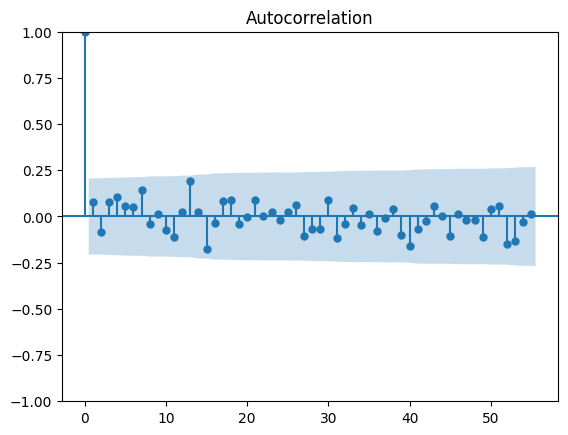

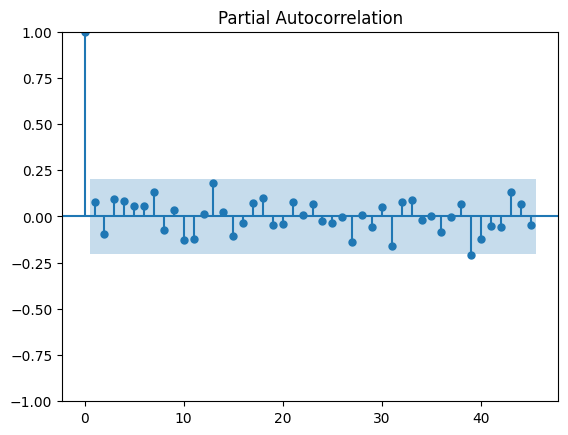

In [ ]:
seasonal_diff1_df = store_df['Weekly_Sales'].diff(periods=52).dropna()

plot_acf(seasonal_diff1_df, lags=55);
plot_pacf(seasonal_diff1_df, lags=45);

#### From this plot I can say that there is no p nor there is q value. And since we have only. <br> After a carefull consideration I will be ustilizing auto arima to find the best parameters. <p>
#### So far I know that the model has seasonality so we will be using Seasonal ARIMA and I want to include exogenous variable so the model which we will be using is SRIMAX model.

## <b> Trial and error

#### After doing lots of guess working with auto arima I have found the best model parameters which I can use for this project for sales forecasting. During each stages I will infrom you why and how I end up using this version and not something other.

## <b> Spliting data into training and testing.

In [20]:
train = store_df['Weekly_Sales'][:'2012-05-01']
test = store_df['Weekly_Sales']['2012-05-01':]

In [21]:
exog_train = store_df['CPI'][:'2012-05-01']
exog_test = store_df['CPI']['2012-05-01':]

#### As you can see I have used CPI as exogenous variable and have not used Holiday_Flags as mentioned in the correlation headmap plot. I did checked with it as a stand alon variable and along with CPI when training model. <p>
#### I have found that the correlation column in the model.summary() was showing an abnormal number which could only mean that this exogenous variable has no use in this model. So i have to drop it off and only go with CPI.

## <b> Final model - SARIMAX (1,0,1)(0,1,0)52

In [22]:
model = SARIMAX(train, exog=exog_train, order=(1,0,1), seasonal_order=(0,1,0,52)).fit(disp=False)
print(model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  117
Model:             SARIMAX(1, 0, 1)x(0, 1, [], 52)   Log Likelihood                -812.675
Date:                             Wed, 15 Apr 2026   AIC                           1633.350
Time:                                     05:51:30   BIC                           1642.048
Sample:                                 02-05-2010   HQIC                          1636.782
                                      - 04-27-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CPI         9985.4621   1521.492      6.563      0.000    7003.392     1.3e+04
ar.L1         -0.2436      

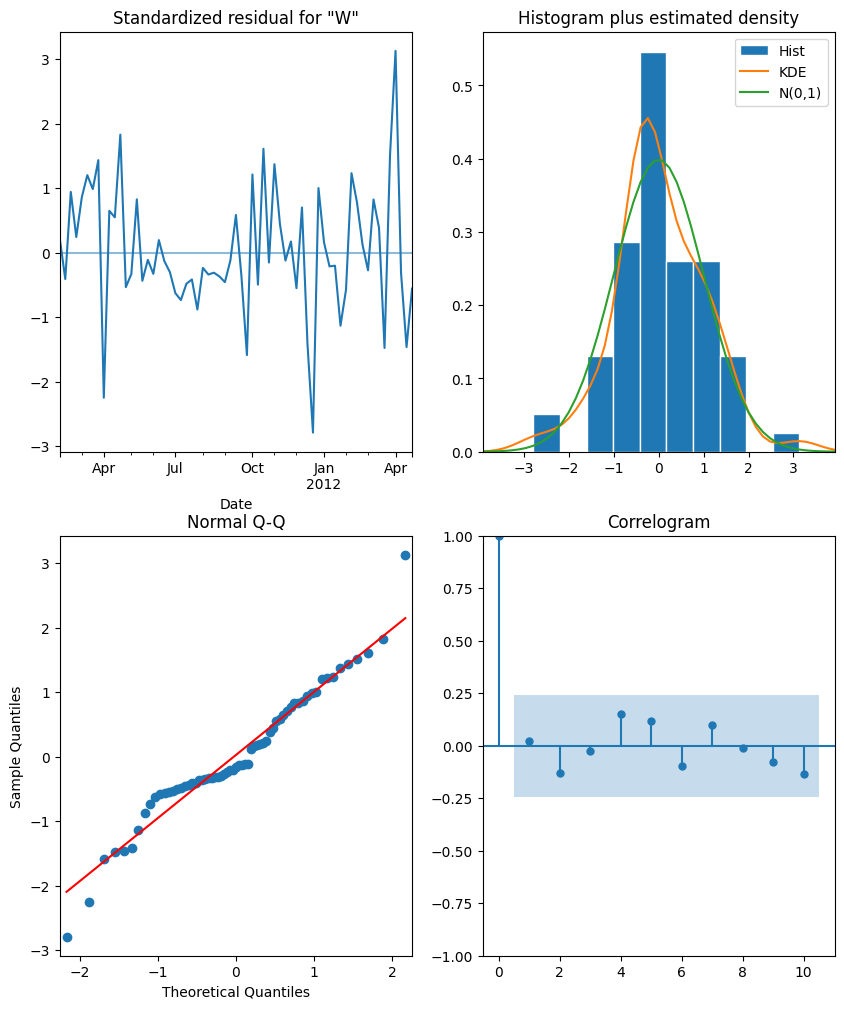

In [ ]:
model.plot_diagnostics(figsize=(10,12));

#### You might be wondering why did I went with this model. The man reason is that, this model has a low AIC and BIC score. Also the residual diagonostics confirms white noise residuals (Ljung-Box (prob(Q)) p > 0.05, Jarque-Bera (prob(JB)) p > 0.05). <P>
#### In layman's term, prob(Q) check how much the model has used the data, i.e. if the lollipops are above the confidence interval (blue shaded region) which is 95% or below 0.05 value then the model didn't utilize the dataset properly. We want the value to be above 0.05. <P/> <P>
#### For the prob(JB), it just shows how well the model has understood the outliers and the noise. We want the value to be above 0.05. <P>
#### Note on sigma² standard error. The near-zero std err for sigma² is a known numerical behaviour of the OPG covariance estimator with this dataset size and model configuration. It does not affect forecast accuracy or residual diagnostics.

## <b> Calculating the RMSE and MAPE for model evaluation.

In [23]:
# Generate the forecast
forecast_object = model.get_forecast(steps=len(test), exog=exog_test)
forecast_mean = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

In [24]:
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
nRMSE = (rmse/test.mean())*100
mape = np.mean(np.abs((test.values - forecast_mean.values) / test.values)) * 100

print(f"RMSE: {rmse:,.0f}")
print(f"nRMSE: {nRMSE:.2f} (RMSE as % of mean sales)")
print(f"MAPE:  {mape:.2f}%")

RMSE: 53,736
nRMSE: 3.41 (RMSE as % of mean sales)
MAPE:  2.50%


#### Saving the model

In [ ]:
import joblib
joblib.dump(model, 'sarimax_store1.pkl')

['sarimax_store1.pkl']

#### Reload the model

In [ ]:
model_loaded = joblib.load('sarimax_store1.pkl')

#### Comparing model forecast with the test data.

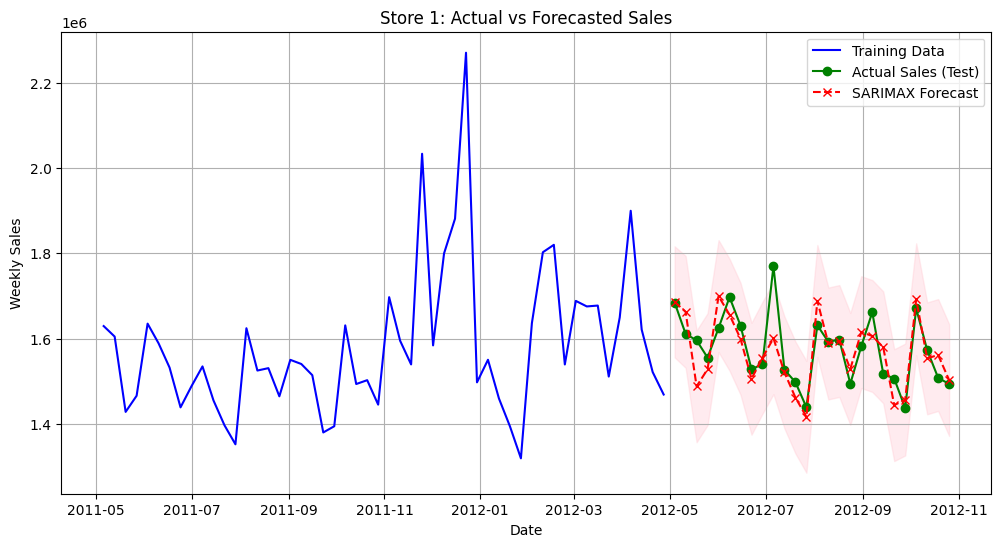

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(train.index[-52:], train[-52:], label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Sales (Test)', color='green', marker='o')
plt.plot(test.index, forecast_mean, label='SARIMAX Forecast', color='red', linestyle='--', marker='x')

plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)

plt.title(f'Store 1: Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

#### Looking at the plot we can say that our model is very good at tracking exsiting data. With this I can confirm that we can use this model for future forecasting of Sales.

## <b> Forecast for the next 20 weeks.

In [25]:
model_fit = SARIMAX(store_df['Weekly_Sales'], exog=store_df['CPI'], order=(1,0,1), seasonal_order=(0,1,0,52)).fit(disp=False)

In [26]:
future_steps = 20

future_dates = pd.date_range(start=store_df.index[-1] + pd.Timedelta(weeks=1), periods=future_steps, freq='W-FRI')
last_cpi_value = store_df['CPI'].iloc[-1]
future_exog = pd.DataFrame({'CPI': [last_cpi_value] * future_steps}, index=future_dates)

future_forecast = model_fit.get_forecast(steps=future_steps, exog=future_exog)
future_forecast_mean = future_forecast.predicted_mean
future_forecast_ci = future_forecast.conf_int()

future_forecast_df = pd.DataFrame({
    'Forecast': future_forecast_mean,
    'Lower CI': future_forecast_ci.iloc[:, 0],
    'Upper CI': future_forecast_ci.iloc[:, 1]
})


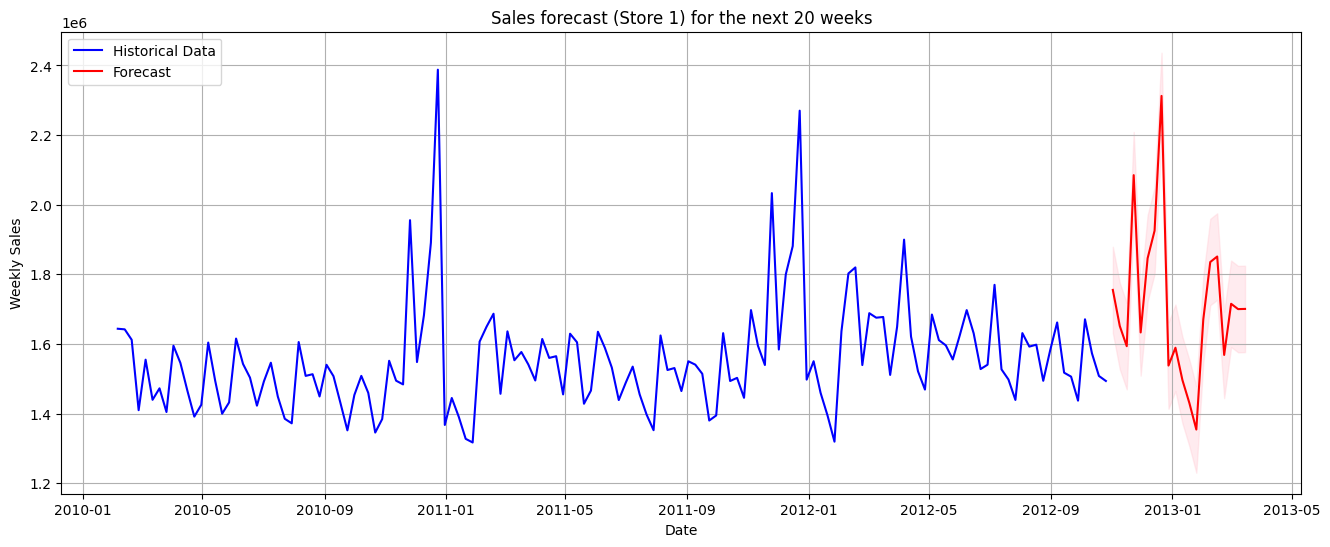

In [27]:

plt.figure(figsize=(16, 6))
plt.plot(store_df['Weekly_Sales'], label='Historical Data', color='blue')
plt.plot(future_forecast_df.index, future_forecast_df['Forecast'], label='Forecast', color='red')

plt.fill_between(future_forecast_df.index, future_forecast_df['Lower CI'], future_forecast_df['Upper CI'], color='pink', alpha=0.3)

plt.title(f"Sales forecast (Store 1) for the next {future_steps} weeks")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid()
plt.show()

## Conclusion
#### The SARIMAX(1,0,1)(0,1,0)[52] model with CPI as exogenous variable. <br>
#### successfully captures the seasonal pattern in Walmart Store 1 weekly sales. <P>
### Key findings:
#### - Strong annual seasonality (s=52 weeks) confirmed by ACF, nsdiffs, and decomposition. <br>
#### - CPI is a statistically significant predictor (p=0.000, coef ≈ +$9,985 per CPI unit). <br>
#### - Residuals pass both Ljung-Box (0.84) and Jarque-Bera (0.17) tests. <br>
#### - Out-of-sample accuracy: MAPE 2.50%, RMSE 53,736. <P>
#### Limitation:
#### - Only 2.8 years of data limits seasonal parameter estimation. <br>
#### - A larger dataset would allow validation across more seasonal cycles.